# ECG Signal Visualization por Clase Diagnóstica
## PTB-XL+ · 500 Hz · 5 clases: NORM, MI, STTC, CD, HYP

Este notebook muestra cómo se ven las señales de electrocardiograma (ECG) para cada una de las 5 clases diagnósticas del dataset PTB-XL+.  
Para cada clase se selecciona un registro representativo (preferentemente puro, es decir sin co-etiquetas) y se visualiza en **formato clínico de 12 derivaciones** con cuadrícula de papel ECG.

## Celda 1 · Imports y configuración

In [1]:
import sys, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from data.labels import build_label_vector, load_scp_statements, CLASSES, CLASS_INDEX

# Paths
DATA_PATH   = PROJECT_ROOT / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset no encontrado: {DATA_PATH}')

# Constantes
SAMPLING_RATE = 500          # Hz
DURATION_S    = 10.0         # segundos por registro
N_SAMPLES     = int(SAMPLING_RATE * DURATION_S)  # 5000 muestras

# Nombres de las 12 derivaciones en orden estándar de PTB-XL
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
              'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Layout clínico 3 filas x 4 columnas
# Fila 0: I, aVR, V1, V4
# Fila 1: II, aVL, V2, V5
# Fila 2: III, aVF, V3, V6
CLINICAL_LAYOUT = [
    [0, 3,  6,  9],
    [1, 4,  7, 10],
    [2, 5,  8, 11],
]

CLASS_DESCRIPTIONS = {
    'NORM': 'Normal ECG — Ritmo sinusal regular, intervalos y morfologia normales',
    'MI':   'Infarto de Miocardio — Elevacion/depresion ST, ondas Q, cambios en onda T',
    'STTC': 'Cambio ST/T — Anomalias de repolarizacion no especificas',
    'CD':   'Trastorno de Conduccion — Bloqueo de rama, bloqueo AV, WPW',
    'HYP':  'Hipertrofia — HVI/HVD: criterios de voltaje y desviacion del eje',
}

CLASS_COLORS = {
    'NORM': '#2E86AB',
    'MI':   '#D62828',
    'STTC': '#F77F00',
    'CD':   '#6A0572',
    'HYP':  '#2D6A4F',
}

plt.rcParams.update({'font.size': 10, 'axes.titlesize': 11})
print(f'Dataset : {DATA_PATH}')
print(f'Figuras : {FIGURES_DIR}')
print(f'Clases  : {CLASSES}')

Dataset : C:\Personal\UP\ML2\ecg-classification\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
Figuras : C:\Personal\UP\ML2\ecg-classification\results\figures
Clases  : ['NORM', 'MI', 'STTC', 'CD', 'HYP']


## Celda 2 · Cargar metadata y seleccionar registros representativos por clase

Para cada clase se busca preferentemente un registro **puro** (con una sola etiqueta activa)  
dentro de los folds de entrenamiento (1-8). Si no existe registro puro, se toma el primer positivo disponible.

In [2]:
# Cargar metadata
db = pd.read_csv(DATA_PATH / 'ptbxl_database.csv', index_col='ecg_id')
code_to_class = load_scp_statements(DATA_PATH / 'scp_statements.csv')

print('Construyendo vectores de etiquetas para todos los registros...')
labels_all = []
for _, row in db.iterrows():
    lbl = build_label_vector(row['scp_codes'], code_to_class)
    labels_all.append(lbl.numpy())

labels_arr = np.stack(labels_all)  # (N, 5)
print(f'Total registros: {len(db):,}  |  Matriz de etiquetas: {labels_arr.shape}')

# Seleccion de representativos
representatives = {}

for cls_name, cls_idx in CLASS_INDEX.items():
    pos_mask  = labels_arr[:, cls_idx] == 1
    pos_idx   = np.where(pos_mask)[0]
    pure_mask = pos_mask & (labels_arr.sum(axis=1) == 1)
    pure_idx  = np.where(pure_mask)[0]

    if len(pure_idx) > 0:
        cands = db.iloc[pure_idx]
        train_cands = cands[cands['strat_fold'].isin(range(1, 9))]
        chosen_row = train_cands.iloc[0] if len(train_cands) > 0 else cands.iloc[0]
        is_pure = True
    else:
        cands = db.iloc[pos_idx]
        train_cands = cands[cands['strat_fold'].isin(range(1, 9))]
        chosen_row = train_cands.iloc[0] if len(train_cands) > 0 else cands.iloc[0]
        is_pure = False

    representatives[cls_name] = {
        'row':    chosen_row,
        'pure':   is_pure,
        'n_pure': len(pure_idx),
        'n_pos':  len(pos_idx),
    }

    label_vec   = build_label_vector(chosen_row['scp_codes'], code_to_class)
    active_cls  = [CLASSES[i] for i in range(5) if label_vec[i] == 1]
    pure_tag    = 'puro' if is_pure else f"co-etiquetas: {', '.join(c for c in active_cls if c != cls_name)}"

    print(
        f'  {cls_name:5s} -> ecg_id={chosen_row.name:5d}  '
        f"fold={int(chosen_row['strat_fold'])}  "
        f"{pure_tag}  "
        f'(puros={len(pure_idx):,}/{len(pos_idx):,} positivos)'
    )

Construyendo vectores de etiquetas para todos los registros...
Total registros: 21,799  |  Matriz de etiquetas: (21799, 5)
  NORM  -> ecg_id=    1  fold=3  puro  (puros=9,097/9,514 positivos)
  MI    -> ecg_id=  131  fold=8  puro  (puros=2,548/5,469 positivos)
  STTC  -> ecg_id=   22  fold=4  puro  (puros=2,387/5,108 positivos)
  CD    -> ecg_id=   32  fold=1  puro  (puros=1,729/4,898 positivos)
  HYP   -> ecg_id=   96  fold=1  puro  (puros=546/2,649 positivos)


## Celda 3 · Funciones de carga y visualizacion ECG

In [3]:
def load_ecg(row, data_path, sampling_rate=500):
    """Carga senial ECG cruda (sin normalizacion). Devuelve (12, N) en mV."""
    col = 'filename_hr' if sampling_rate == 500 else 'filename_lr'
    record_path = (data_path / row[col]).with_suffix('')
    signal, meta = wfdb.rdsamp(str(record_path))  # signal: (N, 12)
    return signal.T.astype(np.float32), meta       # (12, N)


def _draw_ecg_grid(ax, x_range, y_min, y_max):
    """Dibuja la cuadricula de papel ECG en un eje."""
    ax.set_facecolor('#fff8f0')
    x0, x1 = x_range

    # Cuadros pequenos: 0.04 s x 0.1 mV
    for t in np.arange(x0, x1 + 0.04, 0.04):
        ax.axvline(t, color='#f4c2c2', lw=0.25, zorder=0)
    for mv in np.arange(round(y_min / 0.1) * 0.1,
                         round(y_max / 0.1) * 0.1 + 0.1, 0.1):
        ax.axhline(mv, color='#f4c2c2', lw=0.25, zorder=0)

    # Cuadros grandes: 0.2 s x 0.5 mV
    for t in np.arange(x0, x1 + 0.2, 0.2):
        ax.axvline(t, color='#e8a0a0', lw=0.65, zorder=1)
    for mv in np.arange(round(y_min / 0.5) * 0.5,
                         round(y_max / 0.5) * 0.5 + 0.5, 0.5):
        ax.axhline(mv, color='#e8a0a0', lw=0.65, zorder=1)


def plot_ecg_12lead(
    signal,
    sampling_rate,
    suptitle,
    lead_names,
    layout,
    color='#1a1a1a',
    figsize=(18, 7),
    save_path=None,
):
    """
    Visualizacion clinica de 12 derivaciones en layout 3x4.
    Cada columna muestra 2.5 s de senial (4 columnas = 10 s totales).
    """
    n_rows  = len(layout)
    n_cols  = len(layout[0])
    col_dur = DURATION_S / n_cols  # 2.5 s por columna

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize,
                              sharex=False, sharey=False)
    fig.patch.set_facecolor('white')
    fig.suptitle(suptitle, fontsize=12, fontweight='bold', y=1.02)

    for ri, row_leads in enumerate(layout):
        for ci, lead_idx in enumerate(row_leads):
            ax = axes[ri, ci]

            s_start  = int(ci * col_dur * sampling_rate)
            s_end    = int((ci + 1) * col_dur * sampling_rate)
            lead_sig = signal[lead_idx, s_start:s_end]
            t_local  = np.linspace(0, col_dur, len(lead_sig))

            sig_min = lead_sig.min()
            sig_max = lead_sig.max()
            margin  = max((sig_max - sig_min) * 0.15, 0.2)
            y_min   = sig_min - margin
            y_max   = sig_max + margin

            _draw_ecg_grid(ax, (0, col_dur), y_min, y_max)

            ax.plot(t_local, lead_sig, color=color, lw=0.85, zorder=2)

            # Etiqueta de derivacion
            ax.text(0.02, 0.97, lead_names[lead_idx],
                    transform=ax.transAxes, fontsize=10, fontweight='bold',
                    va='top', ha='left',
                    bbox=dict(boxstyle='round,pad=0.15',
                              facecolor='white', edgecolor='none', alpha=0.85))

            ax.set_xlim(0, col_dur)
            ax.set_ylim(y_min, y_max)

            if ri == n_rows - 1:
                ax.set_xlabel('Tiempo (s)', fontsize=8)
                ax.tick_params(axis='x', labelsize=7)
            else:
                ax.tick_params(axis='x', labelbottom=False)

            if ci == 0:
                ax.set_ylabel('mV', fontsize=8)
                ax.tick_params(axis='y', labelsize=7)
            else:
                ax.tick_params(axis='y', labelleft=False)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path.with_suffix('.png'), dpi=200, bbox_inches='tight')
        plt.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        print(f'  Guardado: {save_path.with_suffix(".png")}')

    return fig


print('Funciones listas.')

Funciones listas.


## Celda 4 · Una figura por clase — 12 derivaciones en layout clinico

Cada figura muestra las 12 derivaciones del ECG en el formato estandar de 3 filas x 4 columnas  
(cada columna = 2.5 s, total = 10 s), con cuadricula de papel ECG  
(cuadros pequenos 0.04 s x 0.1 mV, cuadros grandes 0.2 s x 0.5 mV).


  Clase: NORM
  Guardado: C:\Personal\UP\ML2\ecg-classification\results\figures\ecg_signal_norm.png


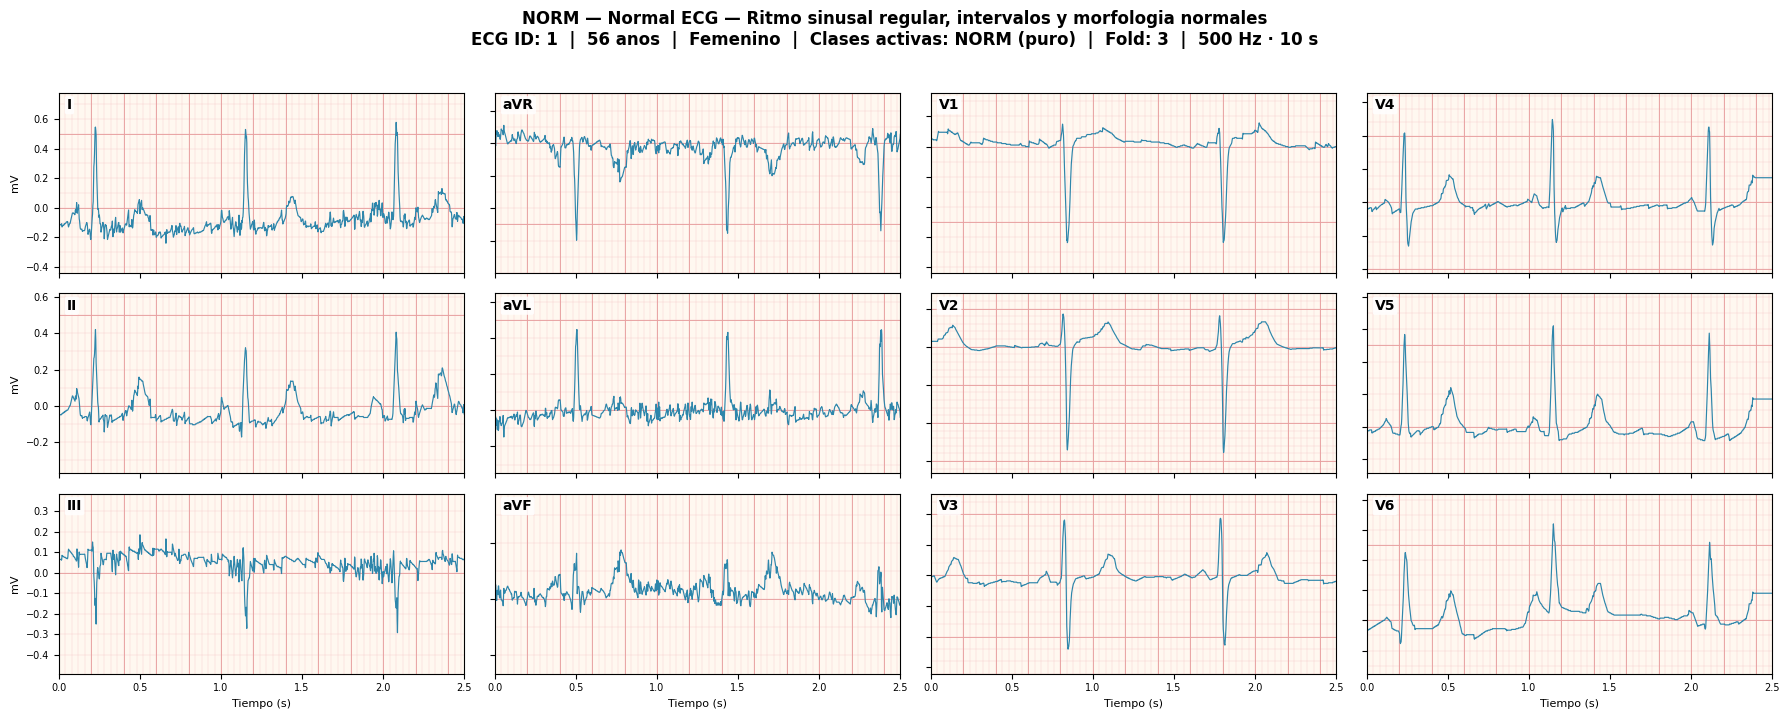


  Clase: MI
  Guardado: C:\Personal\UP\ML2\ecg-classification\results\figures\ecg_signal_mi.png


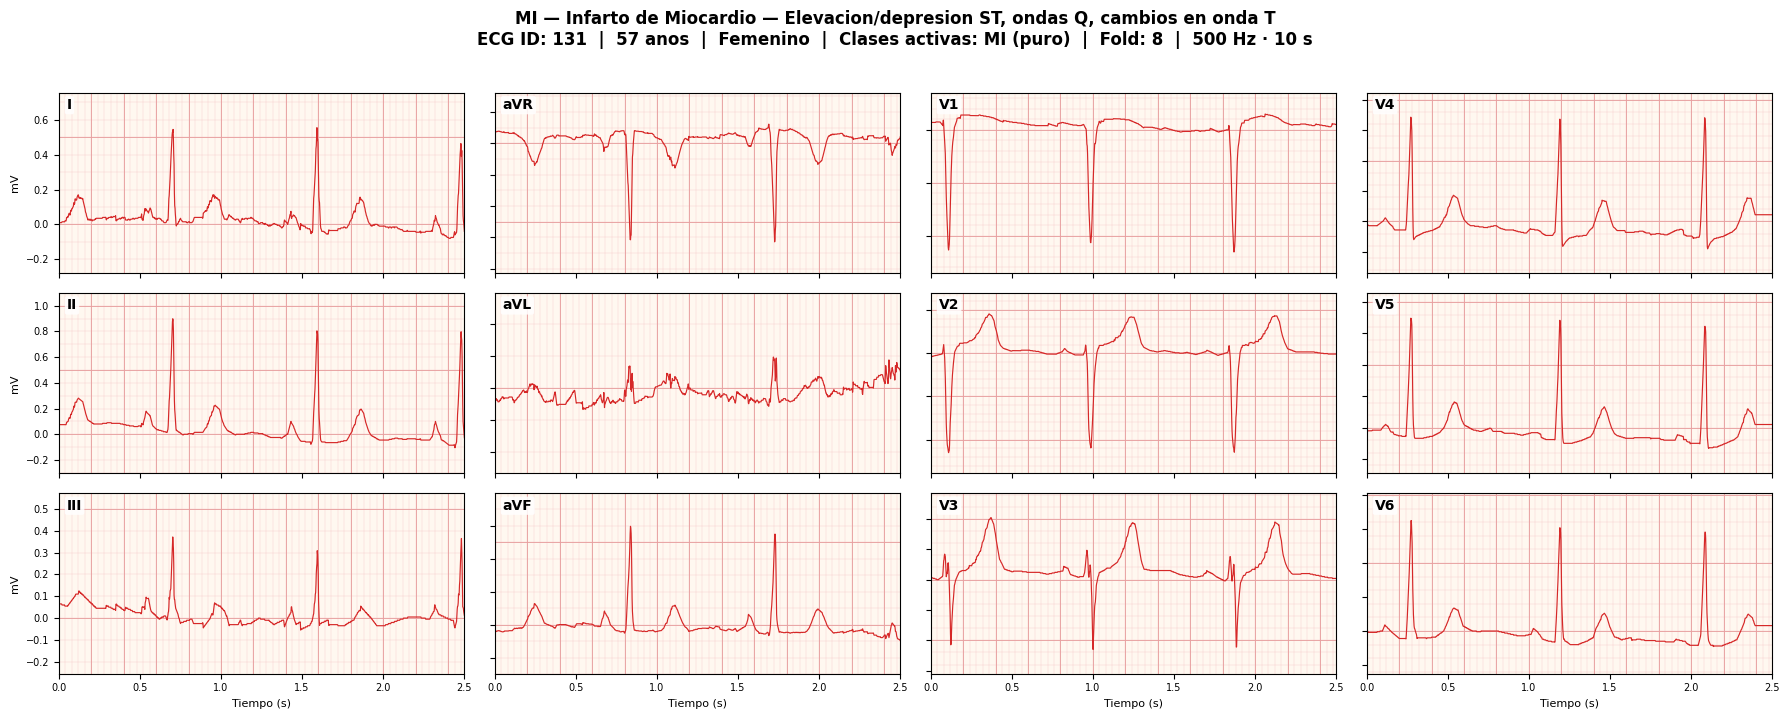


  Clase: STTC
  Guardado: C:\Personal\UP\ML2\ecg-classification\results\figures\ecg_signal_sttc.png


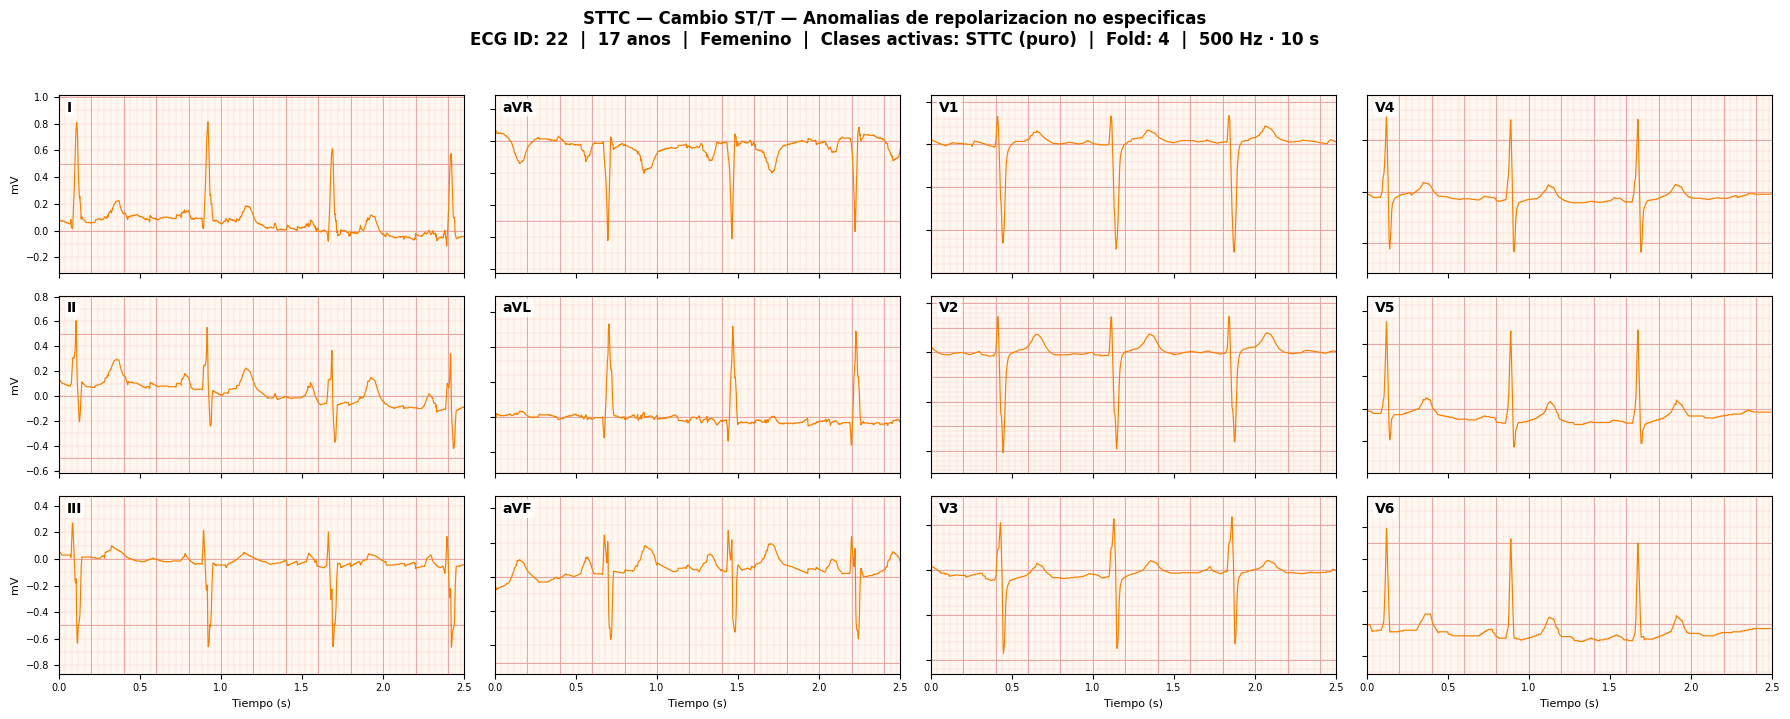


  Clase: CD
  Guardado: C:\Personal\UP\ML2\ecg-classification\results\figures\ecg_signal_cd.png


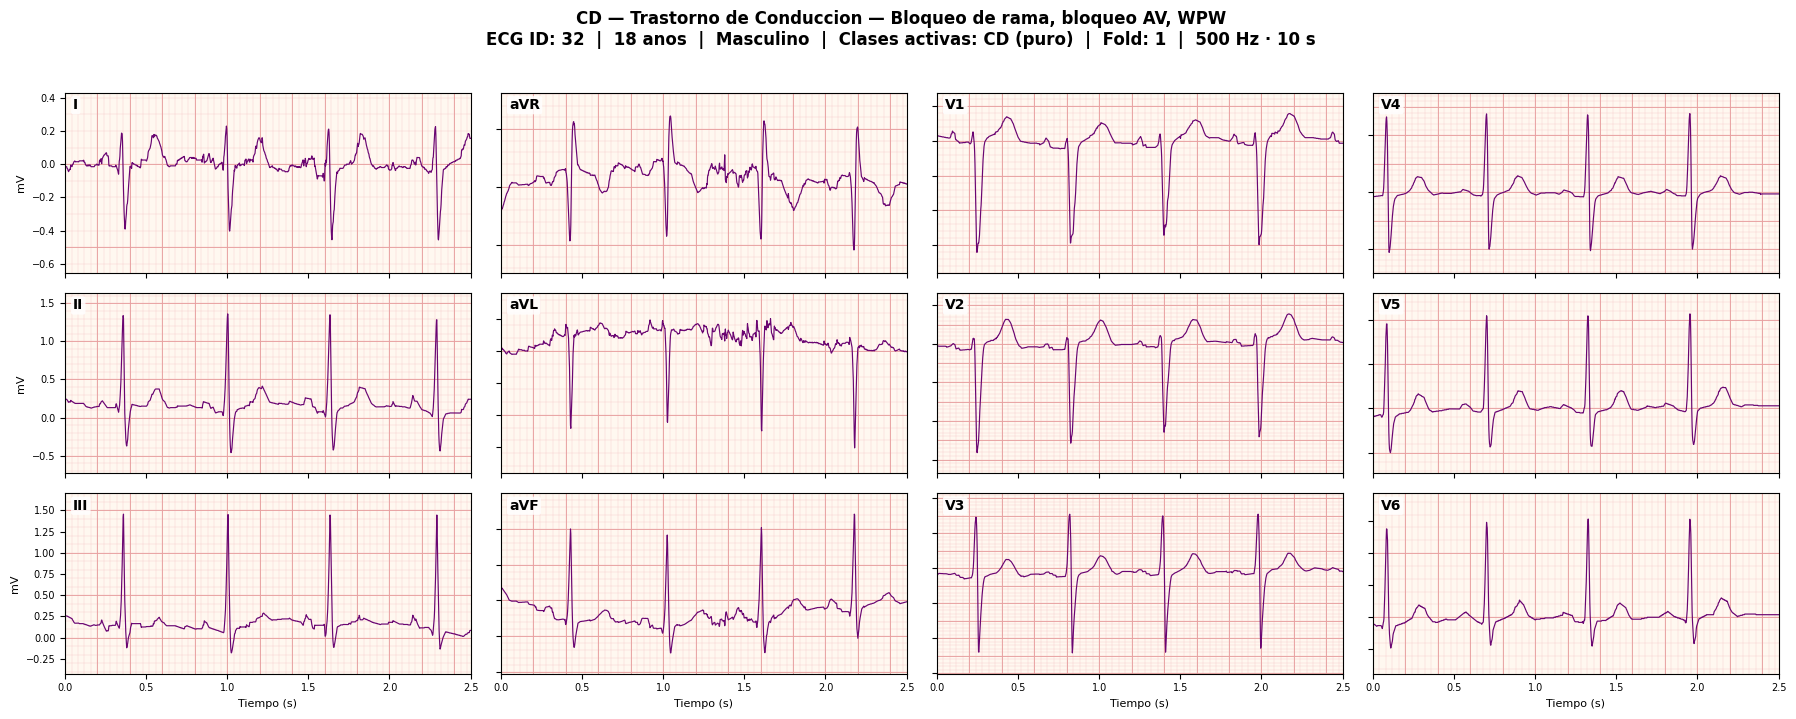


  Clase: HYP
  Guardado: C:\Personal\UP\ML2\ecg-classification\results\figures\ecg_signal_hyp.png


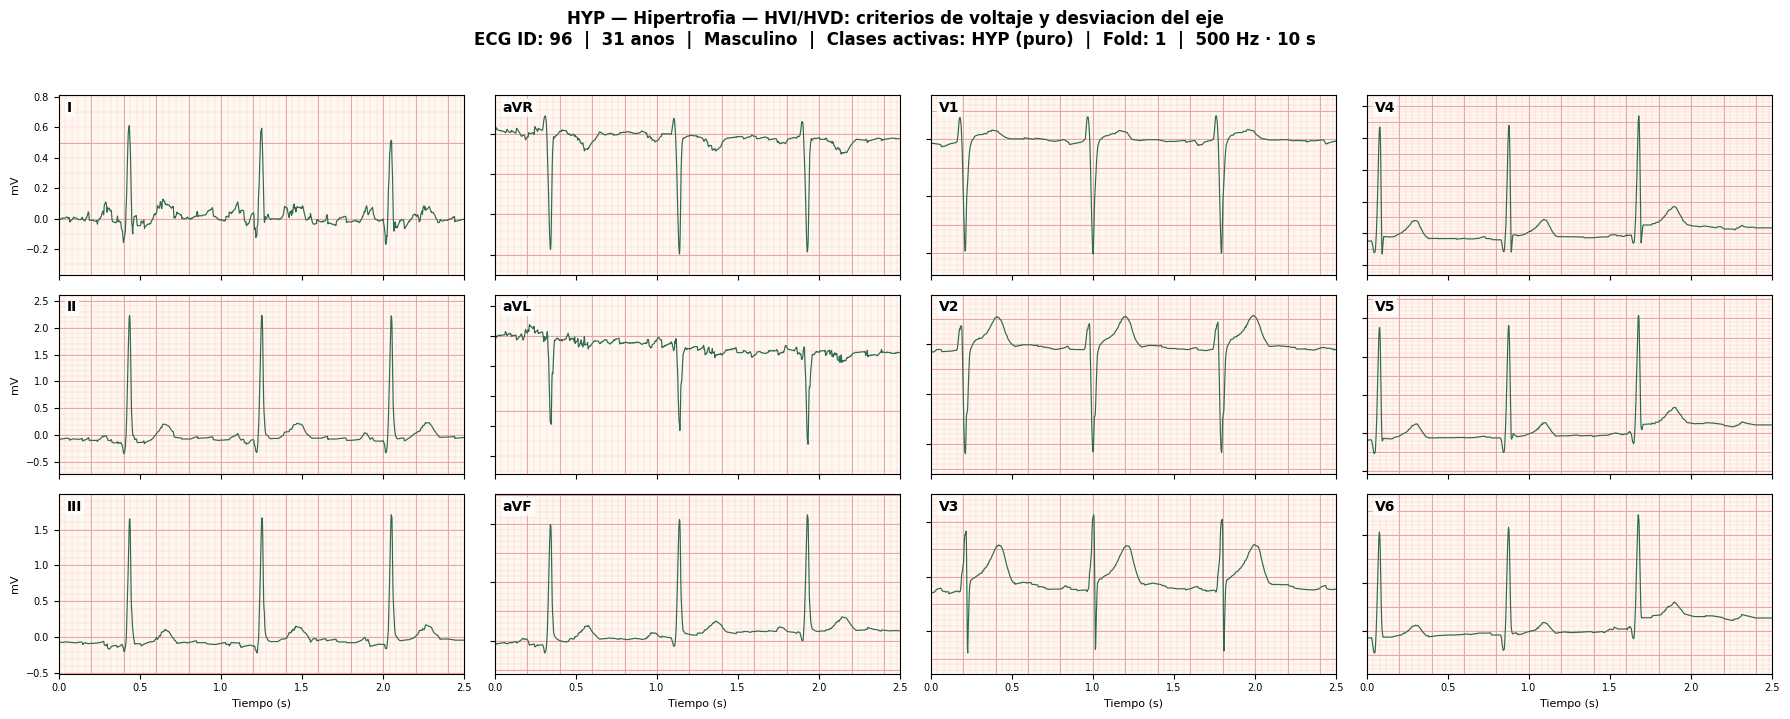

In [4]:
ecg_data = {}  # almacena (signal, meta, row) para reutilizar en celdas siguientes

for cls_name in CLASSES:
    info             = representatives[cls_name]
    row              = info['row']
    signal, meta     = load_ecg(row, DATA_PATH, SAMPLING_RATE)
    ecg_data[cls_name] = (signal, meta, row)

    label_vec  = build_label_vector(row['scp_codes'], code_to_class)
    active_cls = [CLASSES[i] for i in range(5) if label_vec[i] == 1]
    pure_tag   = '(puro)' if info['pure'] else f"(co-etiquetas: {', '.join(c for c in active_cls if c != cls_name)})"

    try:
        age = f"{int(row['age'])} anos"
    except (ValueError, KeyError):
        age = 'edad N/D'

    sex = {0: 'Masculino', 1: 'Femenino'}.get(int(row.get('sex', -1)), 'N/D')

    suptitle = (
        f"{cls_name} — {CLASS_DESCRIPTIONS[cls_name]}\n"
        f"ECG ID: {row.name}  |  {age}  |  {sex}  |  "
        f"Clases activas: {', '.join(active_cls)} {pure_tag}  |  "
        f"Fold: {int(row['strat_fold'])}  |  500 Hz · 10 s"
    )

    print(f"\n{'='*70}")
    print(f'  Clase: {cls_name}')
    print(f"{'='*70}")

    plot_ecg_12lead(
        signal        = signal,
        sampling_rate = SAMPLING_RATE,
        suptitle      = suptitle,
        lead_names    = LEAD_NAMES,
        layout        = CLINICAL_LAYOUT,
        color         = CLASS_COLORS[cls_name],
        figsize       = (18, 7),
        save_path     = FIGURES_DIR / f'ecg_signal_{cls_name.lower()}',
    )
    plt.show()

## Celda 5 · Panel comparativo — Derivacion II en las 5 clases (10 s)

La **Derivacion II** es la mas usada en clinica por mostrar claramente la onda P, el complejo QRS y la onda T.  
Este panel muestra los 10 s completos de la Derivacion II para cada clase diagnostica.

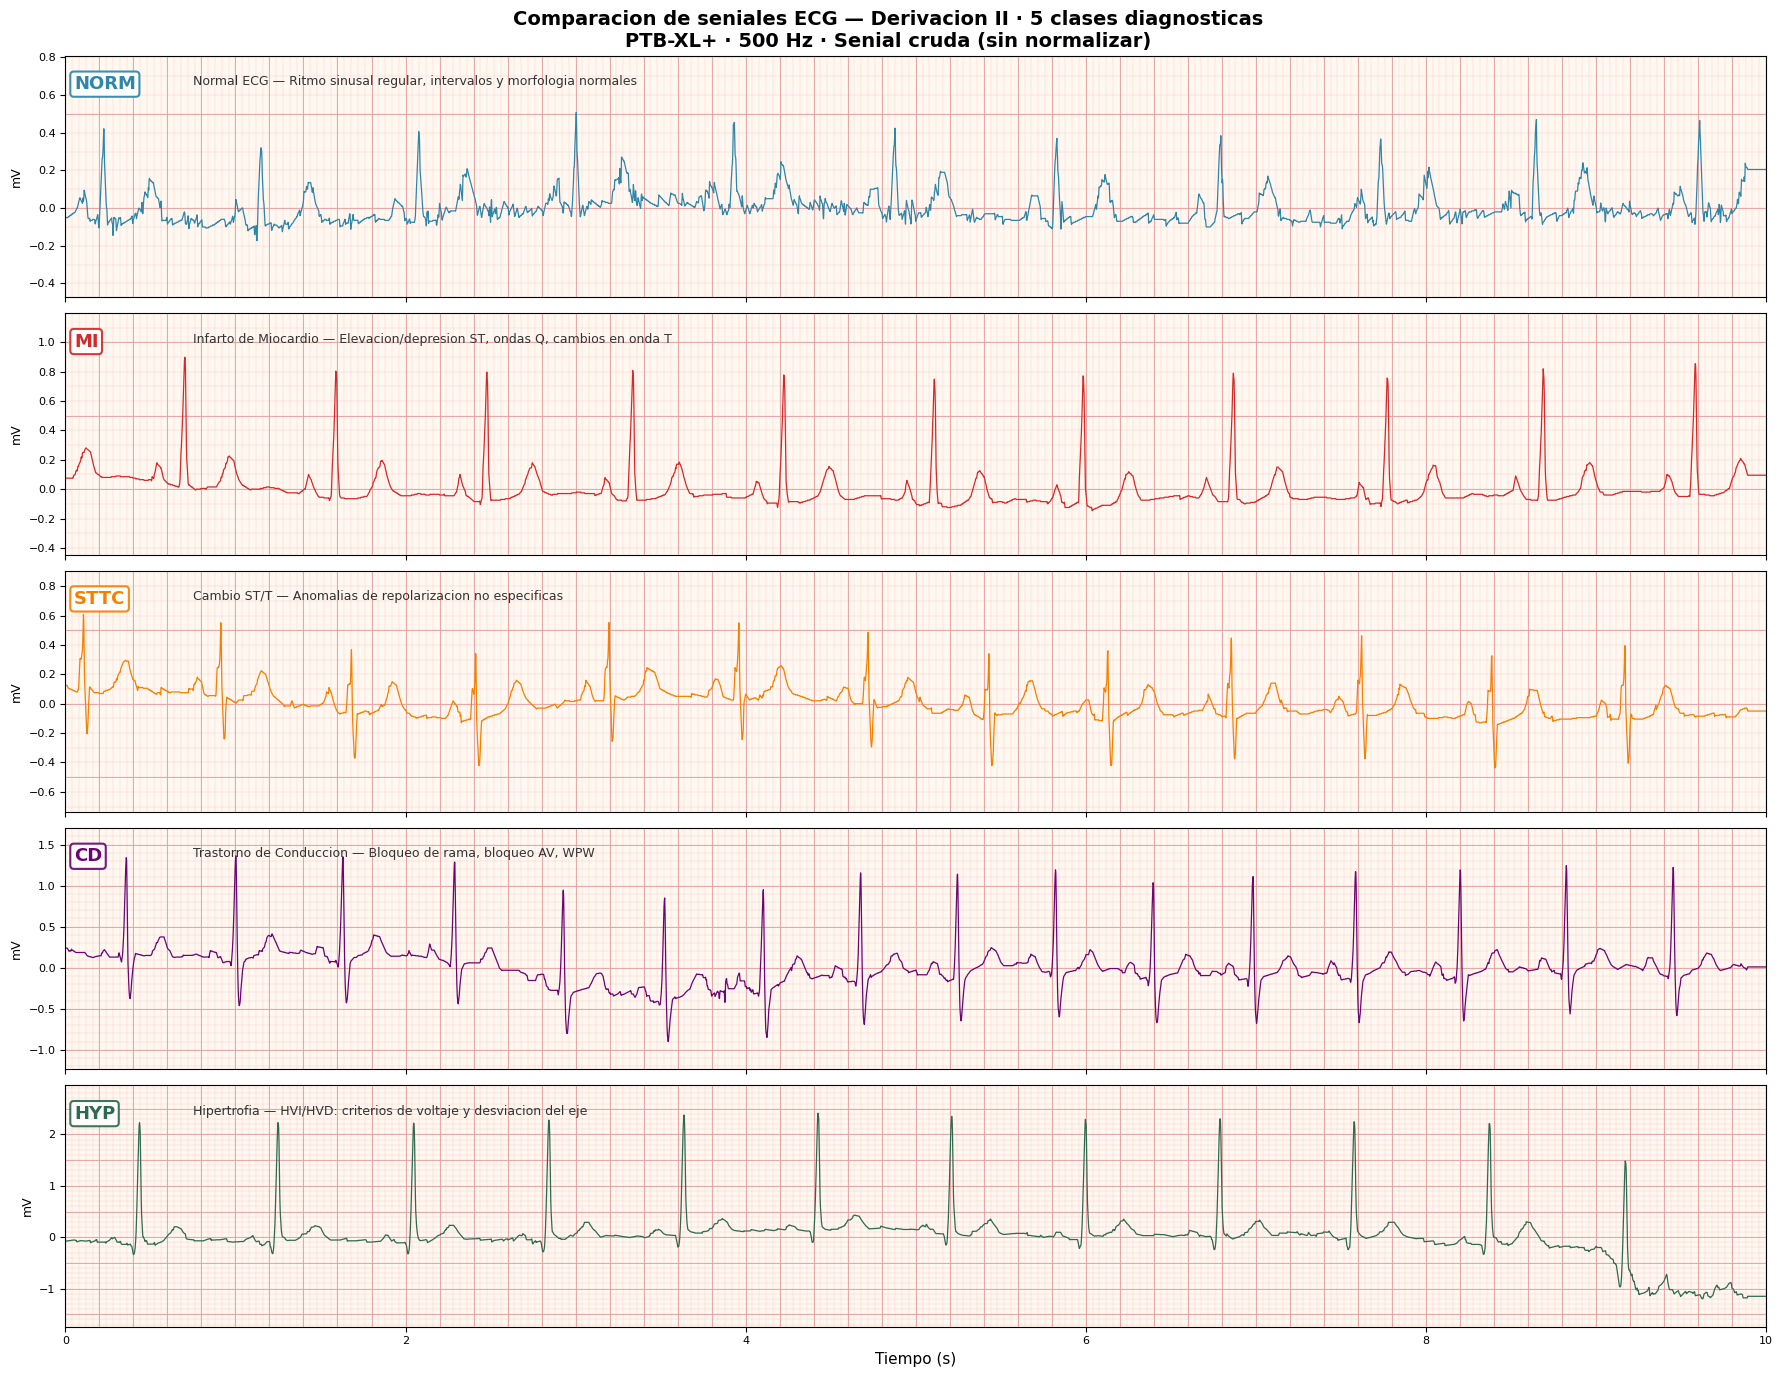

Guardado panel comparativo -> C:\Personal\UP\ML2\ecg-classification\results\figures\ecg_comparison_leadII.png


In [5]:
LEAD_II = 1  # indice de la Derivacion II en PTB-XL

fig, axes = plt.subplots(5, 1, figsize=(18, 14), sharex=True)
fig.patch.set_facecolor('white')
fig.suptitle(
    'Comparacion de seniales ECG — Derivacion II · 5 clases diagnosticas\n'
    'PTB-XL+ · 500 Hz · Senial cruda (sin normalizar)',
    fontsize=14, fontweight='bold'
)

time_s = np.arange(N_SAMPLES) / SAMPLING_RATE

for ax, cls_name in zip(axes, CLASSES):
    signal, _, row = ecg_data[cls_name]
    lead_sig = signal[LEAD_II, :N_SAMPLES]

    sig_min = lead_sig.min()
    sig_max = lead_sig.max()
    margin  = max((sig_max - sig_min) * 0.15, 0.3)
    y_min   = sig_min - margin
    y_max   = sig_max + margin

    _draw_ecg_grid(ax, (0, DURATION_S), y_min, y_max)

    ax.plot(time_s, lead_sig, color=CLASS_COLORS[cls_name], lw=0.9, zorder=2)

    # Etiqueta de clase
    ax.text(
        0.005, 0.92, cls_name,
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        color=CLASS_COLORS[cls_name], va='top',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=CLASS_COLORS[cls_name], linewidth=1.5, alpha=0.92)
    )

    # Descripcion
    ax.text(
        0.075, 0.92, CLASS_DESCRIPTIONS[cls_name],
        transform=ax.transAxes, fontsize=9, va='top', color='#333333'
    )

    ax.set_xlim(0, DURATION_S)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel('mV', fontsize=9)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Tiempo (s)', fontsize=11)
plt.tight_layout(h_pad=0.8)

out_path = FIGURES_DIR / 'ecg_comparison_leadII'
plt.savefig(out_path.with_suffix('.png'), dpi=200, bbox_inches='tight')
plt.savefig(out_path.with_suffix('.pdf'), bbox_inches='tight')
plt.show()
print(f'Guardado panel comparativo -> {out_path.with_suffix(".png")}')

## Celda 6 · Panel compacto — Derivacion II · 2.5 s (zoom morfologico)

Ventana de **2.5 s** para apreciar con mas detalle la morfologia del complejo QRS,  
las ondas P y T, y otros marcadores clinicos relevantes de cada clase.

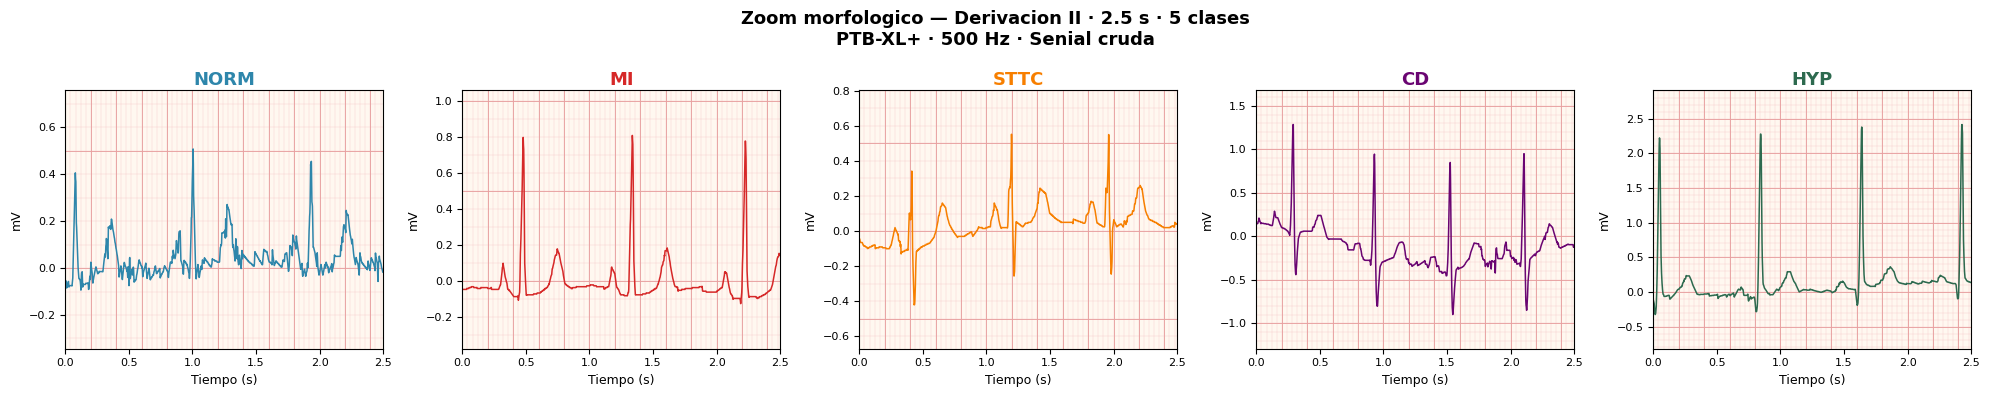

Guardado zoom morfologico -> C:\Personal\UP\ML2\ecg-classification\results\figures\ecg_zoom_leadII.png


In [6]:
ZOOM_S   = 2.5          # segundos a mostrar
ZOOM_N   = int(ZOOM_S * SAMPLING_RATE)
OFFSET_S = 2.0          # empezar desde 2 s (evitar transitorio inicial)
OFFSET_N = int(OFFSET_S * SAMPLING_RATE)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
fig.patch.set_facecolor('white')
fig.suptitle(
    'Zoom morfologico — Derivacion II · 2.5 s · 5 clases\n'
    'PTB-XL+ · 500 Hz · Senial cruda',
    fontsize=13, fontweight='bold'
)

t_zoom = np.linspace(0, ZOOM_S, ZOOM_N)

for ax, cls_name in zip(axes, CLASSES):
    signal, _, row = ecg_data[cls_name]
    lead_sig = signal[LEAD_II, OFFSET_N : OFFSET_N + ZOOM_N]

    sig_min = lead_sig.min()
    sig_max = lead_sig.max()
    margin  = max((sig_max - sig_min) * 0.18, 0.25)
    y_min   = sig_min - margin
    y_max   = sig_max + margin

    _draw_ecg_grid(ax, (0, ZOOM_S), y_min, y_max)

    ax.plot(t_zoom, lead_sig, color=CLASS_COLORS[cls_name], lw=1.1, zorder=2)

    ax.set_title(cls_name, fontsize=13, fontweight='bold',
                 color=CLASS_COLORS[cls_name], pad=4)
    ax.set_xlabel('Tiempo (s)', fontsize=9)
    ax.set_ylabel('mV', fontsize=9)
    ax.set_xlim(0, ZOOM_S)
    ax.set_ylim(y_min, y_max)
    ax.tick_params(labelsize=8)

plt.tight_layout()

out_path = FIGURES_DIR / 'ecg_zoom_leadII'
plt.savefig(out_path.with_suffix('.png'), dpi=200, bbox_inches='tight')
plt.savefig(out_path.with_suffix('.pdf'), bbox_inches='tight')
plt.show()
print(f'Guardado zoom morfologico -> {out_path.with_suffix(".png")}')

## Celda 7 · Resumen de los registros seleccionados

In [7]:
rows_summary = []
for cls_name in CLASSES:
    info             = representatives[cls_name]
    row              = info['row']
    signal, _, _     = ecg_data[cls_name]
    lead_ii          = signal[LEAD_II]

    label_vec  = build_label_vector(row['scp_codes'], code_to_class)
    active_cls = [CLASSES[i] for i in range(5) if label_vec[i] == 1]

    rows_summary.append({
        'Clase':             cls_name,
        'ECG ID':            int(row.name),
        'Fold':              int(row['strat_fold']),
        'Edad':              f"{row.get('age', float('nan')):.0f}",
        'Sexo':              {0: 'M', 1: 'F'}.get(int(row.get('sex', -1)), 'N/D'),
        'Etiquetas activas': ', '.join(active_cls),
        'Puro':              'Si' if info['pure'] else 'No',
        'Registros puros':   f"{info['n_pure']:,}",
        'Total positivos':   f"{info['n_pos']:,}",
        'Lead II min (mV)':  f'{lead_ii.min():.3f}',
        'Lead II max (mV)':  f'{lead_ii.max():.3f}',
        'Lead II std (mV)':  f'{lead_ii.std():.3f}',
    })

summary_df = pd.DataFrame(rows_summary).set_index('Clase')
print('Resumen de registros representativos seleccionados:')
display(summary_df)

Resumen de registros representativos seleccionados:


,ECG ID,Fold,Edad,Sexo,Etiquetas activas,Puro,Registros puros,Total positivos,Lead II min (mV),Lead II max (mV),Lead II std (mV)
Clase,,,,,,,,,,,
NORM,1,3,56,F,NORM,Si,"9,097","9,514",-0.173,0.508,0.086
MI,131,8,57,F,MI,Si,"2,548","5,469",-0.146,0.899,0.127
STTC,22,4,17,F,STTC,Si,"2,387","5,108",-0.437,0.606,0.106
CD,32,1,18,M,CD,Si,"1,729","4,898",-0.898,1.363,0.240
HYP,96,1,31,M,HYP,Si,546,"2,649",-1.200,2.414,0.449


## Celda 8 · Señales normalizadas — Crudo vs Z-score (Derivación II)

El modelo recibe las señales con **normalización z-score por derivación** ajustada sobre el
conjunto de entrenamiento (calculada por `scripts/preprocess.py` y guardada en `config/norm_stats.npy`):

$$x_{\text{norm}} = \frac{x - \mu_{\text{lead}}}{\sigma_{\text{lead}}}$$

Después de la normalización la señal pierde su unidad (mV) y queda en unidades de desviación estándar.  
La morfología se conserva; solo cambia la escala absoluta.

In [ ]:
from data.preprocessing import load_norm_stats

# Cargar estadísticas de normalización (generadas por scripts/preprocess.py)
norm_stats_path = PROJECT_ROOT / 'config' / 'norm_stats.npy'
if not norm_stats_path.exists():
    raise FileNotFoundError(
        f'No se encontró: {norm_stats_path}\n'
        'Ejecutar primero: python scripts/preprocess.py'
    )

norm_mean, norm_std = load_norm_stats(norm_stats_path)  # (12, 1) cada uno
print(f'norm_stats cargadas desde: {norm_stats_path}')
print(f'  mean shape: {norm_mean.shape}  |  std shape: {norm_std.shape}')
print()

# Tabla de estadísticas por derivación
stats_rows = []
for i, lead in enumerate(LEAD_NAMES):
    stats_rows.append({
        'Derivación': lead,
        'mean (mV)':  f'{norm_mean[i, 0]:.5f}',
        'std (mV)':   f'{norm_std[i, 0]:.5f}',
    })
stats_df = pd.DataFrame(stats_rows).set_index('Derivación')
print('Estadísticas de normalización (training set):')
display(stats_df)

# ── Panel: Crudo vs Normalizado — Derivación II · 5 clases ──────────────────
fig, axes = plt.subplots(5, 2, figsize=(20, 14),
                          gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.08})
fig.patch.set_facecolor('white')
fig.suptitle(
    'Derivación II — Crudo vs Normalizado (z-score por derivación)\n'
    'PTB-XL+ · 500 Hz · 10 s',
    fontsize=14, fontweight='bold'
)

axes[0, 0].set_title('Crudo (mV)',            fontsize=12, fontweight='bold', pad=8)
axes[0, 1].set_title('Normalizado (z-score)', fontsize=12, fontweight='bold', pad=8)

time_s = np.arange(N_SAMPLES) / SAMPLING_RATE

for row_i, cls_name in enumerate(CLASSES):
    signal_raw, _, _ = ecg_data[cls_name]

    # z-score: (12, N) - (12, 1) / (12, 1)  →  broadcast automático
    signal_norm = (signal_raw - norm_mean) / norm_std

    color = CLASS_COLORS[cls_name]

    for col_i, (sig, ylabel, is_norm) in enumerate([
        (signal_raw,  'mV',      False),
        (signal_norm, 'z-score', True),
    ]):
        ax       = axes[row_i, col_i]
        lead_sig = sig[LEAD_II, :N_SAMPLES]

        sig_min = lead_sig.min()
        sig_max = lead_sig.max()
        margin  = max((sig_max - sig_min) * 0.15, 0.5)
        y_min   = sig_min - margin
        y_max   = sig_max + margin

        ax.set_facecolor('#f9f9f9')
        ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
        ax.grid(True, which='major', color='#e0e0e0', lw=0.5, zorder=0)

        ax.plot(time_s, lead_sig, color=color, lw=0.85, zorder=2)

        # Etiqueta de clase (solo columna izquierda)
        if col_i == 0:
            ax.text(
                0.005, 0.93, cls_name,
                transform=ax.transAxes, fontsize=12, fontweight='bold',
                color=color, va='top',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=color, linewidth=1.5, alpha=0.92)
            )

        ax.set_xlim(0, DURATION_S)
        ax.set_ylim(y_min, y_max)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.tick_params(labelsize=8)

        if row_i < 4:
            ax.tick_params(axis='x', labelbottom=False)
        else:
            ax.set_xlabel('Tiempo (s)', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])

out_path = FIGURES_DIR / 'ecg_raw_vs_norm_leadII'
plt.savefig(out_path.with_suffix('.png'), dpi=200, bbox_inches='tight')
plt.savefig(out_path.with_suffix('.pdf'), bbox_inches='tight')
plt.show()
print(f'Guardado → {out_path.with_suffix(".png")}')

## Celda 9 · Señal normalizada — 12 derivaciones por clase (vista del modelo)

Esta es exactamente la representación que recibe el **ResNet-1D** durante el entrenamiento  
(sin aumentación de datos, solo z-score). El eje Y ahora está en unidades de desviación  
estándar, no en mV. El fondo azulado distingue visualmente esta vista de la cruda.

In [ ]:
def plot_ecg_12lead_norm(signal, sampling_rate, suptitle, lead_names, layout,
                          color='#1a1a1a', figsize=(18, 7), save_path=None):
    """Layout 12 derivaciones para señal normalizada (eje Y en z-score)."""
    n_rows  = len(layout)
    n_cols  = len(layout[0])
    col_dur = DURATION_S / n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize,
                              sharex=False, sharey=False)
    fig.patch.set_facecolor('white')
    fig.suptitle(suptitle, fontsize=12, fontweight='bold', y=1.02)

    for ri, row_leads in enumerate(layout):
        for ci, lead_idx in enumerate(row_leads):
            ax = axes[ri, ci]

            s_start  = int(ci * col_dur * sampling_rate)
            s_end    = int((ci + 1) * col_dur * sampling_rate)
            lead_sig = signal[lead_idx, s_start:s_end]
            t_local  = np.linspace(0, col_dur, len(lead_sig))

            sig_min = lead_sig.min()
            sig_max = lead_sig.max()
            margin  = max((sig_max - sig_min) * 0.15, 0.5)
            y_min   = sig_min - margin
            y_max   = sig_max + margin

            ax.set_facecolor('#f0f4ff')          # azul suave → distingue de señal cruda
            ax.axhline(0, color='#9ab0d4', lw=0.8, zorder=0)
            ax.grid(True, color='#ccd9f0', lw=0.4, zorder=0)

            ax.plot(t_local, lead_sig, color=color, lw=0.85, zorder=2)

            ax.text(0.02, 0.97, lead_names[lead_idx],
                    transform=ax.transAxes, fontsize=10, fontweight='bold',
                    va='top', ha='left',
                    bbox=dict(boxstyle='round,pad=0.15',
                              facecolor='white', edgecolor='none', alpha=0.85))

            ax.set_xlim(0, col_dur)
            ax.set_ylim(y_min, y_max)

            if ri == n_rows - 1:
                ax.set_xlabel('Tiempo (s)', fontsize=8)
                ax.tick_params(axis='x', labelsize=7)
            else:
                ax.tick_params(axis='x', labelbottom=False)

            if ci == 0:
                ax.set_ylabel('z-score', fontsize=8)
                ax.tick_params(axis='y', labelsize=7)
            else:
                ax.tick_params(axis='y', labelleft=False)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path.with_suffix('.png'), dpi=200, bbox_inches='tight')
        plt.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        print(f'  Guardado: {save_path.with_suffix(".png")}')

    return fig


# Una figura normalizada de 12 derivaciones por clase
for cls_name in CLASSES:
    signal_raw, _, row = ecg_data[cls_name]
    signal_norm        = (signal_raw - norm_mean) / norm_std

    label_vec  = build_label_vector(row['scp_codes'], code_to_class)
    active_cls = [CLASSES[i] for i in range(5) if label_vec[i] == 1]

    l2_raw  = signal_raw[LEAD_II]
    l2_norm = signal_norm[LEAD_II]

    suptitle = (
        f"{cls_name} — Vista del modelo (z-score por derivación)\n"
        f"ECG ID: {row.name}  |  Clases: {', '.join(active_cls)}  |  "
        f"Lead II crudo: {l2_raw.mean():.3f} ± {l2_raw.std():.3f} mV  →  "
        f"norm: {l2_norm.mean():.3f} ± {l2_norm.std():.3f} σ"
    )

    print(f"\n{'='*70}")
    print(f'  Clase: {cls_name}  (normalizado)')
    print(f"{'='*70}")

    plot_ecg_12lead_norm(
        signal        = signal_norm,
        sampling_rate = SAMPLING_RATE,
        suptitle      = suptitle,
        lead_names    = LEAD_NAMES,
        layout        = CLINICAL_LAYOUT,
        color         = CLASS_COLORS[cls_name],
        figsize       = (18, 7),
        save_path     = FIGURES_DIR / f'ecg_norm_{cls_name.lower()}',
    )
    plt.show()

## Celda 10 · Distribución de amplitudes: Crudo vs Normalizado

Histograma de amplitudes de la **Derivación II** para los 5 registros representativos,  
antes y después de la normalización. Permite ver cómo el z-score centra y escala cada señal.

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Distribución de amplitudes — Derivación II\n'
    'Crudo (fila superior) vs Normalizado z-score (fila inferior)',
    fontsize=13, fontweight='bold'
)

for col_i, cls_name in enumerate(CLASSES):
    signal_raw, _, _ = ecg_data[cls_name]
    signal_norm      = (signal_raw - norm_mean) / norm_std

    raw_vals  = signal_raw[LEAD_II]
    norm_vals = signal_norm[LEAD_II]
    color     = CLASS_COLORS[cls_name]

    # Fila superior: señal cruda
    ax_raw = axes[0, col_i]
    ax_raw.hist(raw_vals, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax_raw.axvline(raw_vals.mean(), color='black', lw=1.5, ls='--',
                   label=f'μ = {raw_vals.mean():.3f}')
    ax_raw.set_title(cls_name, fontsize=12, fontweight='bold', color=color)
    ax_raw.set_xlabel('Amplitud (mV)', fontsize=9)
    ax_raw.set_ylabel('Frecuencia', fontsize=9)
    ax_raw.legend(fontsize=8)
    ax_raw.tick_params(labelsize=8)
    ax_raw.text(0.97, 0.88, f'σ = {raw_vals.std():.3f}',
                transform=ax_raw.transAxes, fontsize=8,
                ha='right', va='top', color='#555555')

    # Fila inferior: señal normalizada
    ax_norm = axes[1, col_i]
    ax_norm.hist(norm_vals, bins=60, color=color, alpha=0.6, edgecolor='none')
    ax_norm.axvline(norm_vals.mean(), color='black', lw=1.5, ls='--',
                    label=f'μ = {norm_vals.mean():.3f}')
    ax_norm.set_xlabel('Amplitud (z-score)', fontsize=9)
    ax_norm.set_ylabel('Frecuencia', fontsize=9)
    ax_norm.legend(fontsize=8)
    ax_norm.tick_params(labelsize=8)
    ax_norm.text(0.97, 0.88, f'σ = {norm_vals.std():.3f}',
                 transform=ax_norm.transAxes, fontsize=8,
                 ha='right', va='top', color='#555555')

plt.tight_layout(rect=[0, 0, 1, 0.94])

out_path = FIGURES_DIR / 'ecg_amplitude_dist'
plt.savefig(out_path.with_suffix('.png'), dpi=200, bbox_inches='tight')
plt.savefig(out_path.with_suffix('.pdf'), bbox_inches='tight')
plt.show()
print(f'Guardado → {out_path.with_suffix(".png")}')